# Midterm project: расход топлива автомобилей (Vehicle fuel efficiency)

## Этап 1. Постановка задачи (Problem and scope)

**Вопрос проекта:** можно ли предсказать комбинированный расход топлива нового легкового автомобиля по его базовым характеристикам (год выпуска, объём двигателя, число цилиндров, класс, тип трансмиссии, тип топлива)?

**Тип задачи:** регрессия.
**Target (зафиксирован):** `Combined (L/100 km)`: комбинированный расход, л на 100 км.

**Метрики:**
- **MAE** (л/100 км): основная метрика, легко интерпретируется;
- **RMSE** (л/100 км): сильнее штрафует крупные ошибки;
- **R²**: доля объяснённой дисперсии.

**Критерий успеха:** MAE лучшей модели на test как минимум на 50% ниже MAE baseline (предсказание среднего значения target на train). Порог можно уточнить после первых результатов.

**Контекст и объём:** данные Natural Resources Canada за 2014-2025 годы (11829 строк). В данных нет веса и мощности автомобиля, поэтому вместо них модели опираются на объём двигателя, число цилиндров и класс автомобиля. Это ограничение учитываем при анализе ошибок. План: очистка и EDA, feature engineering, split с защитой от утечки (group split по паре `Make` + `Model`), baseline, Linear Regression, Decision Tree, KNN, cross-validation, анализ ошибок.

# Этап 2. Загрузка и первичный осмотр данных

**Источник данных:** Natural Resources Canada, Fuel Consumption Ratings (Open Canada), официальная страница набора: https://open.canada.ca/data/en/dataset/98f1a129-f628-4ce4-b24d-6f16bf24dd64
**Лицензия:** Open Government Licence - Canada.
**Откуда загружаем в коде:** копия этих данных в GitHub-репозитории `bgl2427/fuel-efficiency`, файл `fuel_consumption_2014_2025.csv` (ссылка `CSV_URL` в ячейке ниже). Размер: 11829 строк, 15 столбцов, около 960 КБ. Годы 2015-2024 мы сверили с официальным файлом 2015-2024: число строк по годам, распределение `Fuel type`, статистика target и число пропусков совпадают. Для 2014 и 2025 отдельной сверки с официальным файлом не делали.
**Что используем:** весь файл, модельные годы **2014-2025** (11829 строк, 15 столбцов): основной набор для обучения и тестирования. Файлы 1995-2013 не смешиваем: у них рейтинги пересчитаны по другой методике.
**Известные особенности:** нет веса и мощности; `CO2 rating` и `Smog rating` пропущены за первые годы; несколько столбцов напрямую выражают target (см. 3.7).

**Как получаем данные:**
1. `pd.read_csv` читает CSV прямо по ссылке `CSV_URL`, локальные файлы не нужны, поэтому ноутбук запускается у всех участников одинаково.
2. `df.columns.str.strip()` убирает случайные пробелы в названиях столбцов.

In [1]:
import pandas as pd

CSV_URL = "https://raw.githubusercontent.com/bgl2427/fuel-efficiency/refs/heads/main/fuel_consumption_2014_2025.csv"
df = pd.read_csv(CSV_URL)
df.columns = df.columns.str.strip()

### Размер данных

`df.shape` показывает число строк и столбцов.

**Результат:** (11829, 15), то есть 11829 автомобилей и 15 столбцов.
**Вывод:** для Linear Regression, Decision Tree и KNN этого достаточно, модели обучаются быстро.

In [2]:
print(df.shape)

(11829, 15)


### Типы данных и пропуски

`df.info()` показывает тип каждого столбца и сколько в нём непустых значений.

**Результат:**
- Типы: 6 столбцов float64, 4 int64, 5 текстовых (`object`).
- Пропуски есть только в двух столбцах: `CO2 rating` (9633 из 11829 заполнены) и `Smog rating` (8527 из 11829).

**Вывод:** оба столбца с пропусками мы всё равно не берём в признаки из-за утечки данных (см. ниже), поэтому заполнять пропуски не нужно.

In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 11829 entries, 0 to 11828
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model year            11829 non-null  int64  
 1   Make                  11829 non-null  str    
 2   Model                 11829 non-null  str    
 3   Vehicle class         11829 non-null  str    
 4   Engine size (L)       11829 non-null  float64
 5   Cylinders             11829 non-null  int64  
 6   Transmission          11829 non-null  str    
 7   Fuel type             11829 non-null  str    
 8   City (L/100 km)       11829 non-null  float64
 9   Highway (L/100 km)    11829 non-null  float64
 10  Combined (L/100 km)   11829 non-null  float64
 11  Combined (mpg)        11829 non-null  int64  
 12  CO2 emissions (g/km)  11829 non-null  int64  
 13  CO2 rating            9633 non-null   float64
 14  Smog rating           8527 non-null   float64
dtypes: float64(6), int64(4), str(5

### Первые строки

`df.head()` показывает первые 5 строк, чтобы увидеть, как выглядят данные.

**Что видно:**
- Данные начинаются с 2014 года, значит, загружен весь файл 2014-2025.
- `Vehicle class` содержит составные названия (например, `Compact` и `Sport utility vehicle: Small`). Единообразие записи проверим в 3.3.
- `Transmission` состоит из типа и числа передач (`AS5`, `M6`, `AV7`): из неё можно сделать два признака.
- `Fuel type` закодирован буквами.
- В названии модели встречаются гибриды (например, `ILX Hybrid`).

In [4]:
print(df.head())

   Model year   Make       Model                 Vehicle class  \
0        2014  Acura         ILX                       Compact   
1        2014  Acura         ILX                       Compact   
2        2014  Acura  ILX Hybrid                       Compact   
3        2014  Acura     MDX 4WD  Sport utility vehicle: Small   
4        2014  Acura     RDX AWD  Sport utility vehicle: Small   

   Engine size (L)  Cylinders Transmission Fuel type  City (L/100 km)  \
0              2.0          4          AS5         Z              9.9   
1              2.4          4           M6         Z             11.2   
2              1.5          4          AV7         Z              6.0   
3              3.5          6          AS6         Z             12.7   
4              3.5          6          AS6         Z             12.1   

   Highway (L/100 km)  Combined (L/100 km)  Combined (mpg)  \
0                 6.7                  8.5              33   
1                 7.7                  9

### Список столбцов

`df.columns.tolist()` выводит точные названия столбцов, чтобы обращаться к ним в коде без опечаток.

**Кандидаты в признаки:** `Model year`, `Make`, `Model`, `Vehicle class`, `Engine size (L)`, `Cylinders`, `Transmission`, `Fuel type`.

**Target:** `Combined (L/100 km)`.

**Исключаем из признаков (data leakage):** `City (L/100 km)`, `Highway (L/100 km)`, `Combined (mpg)`, `CO2 emissions (g/km)`, `CO2 rating`, `Smog rating`. Они напрямую выражают target или считаются из него, и модель получила бы ответ вместо того, чтобы его предсказывать.

In [5]:
print(df.columns.tolist())

['Model year', 'Make', 'Model', 'Vehicle class', 'Engine size (L)', 'Cylinders', 'Transmission', 'Fuel type', 'City (L/100 km)', 'Highway (L/100 km)', 'Combined (L/100 km)', 'Combined (mpg)', 'CO2 emissions (g/km)', 'CO2 rating', 'Smog rating']


### Диапазон лет, типы топлива и статистика

В ячейке три проверки:
1. Минимум и максимум года. **Результат:** 2014 и 2025.
2. `value_counts()` по `Fuel type`. **Результат:** X: 5574, Z: 5559, E: 423, D: 272, N: 1. Категории очень разной частоты, а `N` встречается всего один раз (решение по нему примем при очистке). Расшифровка букв по документации NRCan: X: regular gasoline, Z: premium gasoline, D: diesel, E: ethanol (E85), N: natural gas. Сверьте с Data Dictionary на странице набора данных.
3. `describe()`: минимум, максимум, среднее по числовым столбцам.

**Что видно в `describe()`:**
- Target `Combined (L/100 km)`: от 4.0 до 26.1, среднее около 11.0, std около 2.9. Разброс достаточный, чтобы было что предсказывать.
- Объём двигателя 0.9-8.4 л, цилиндры 3-16: значения правдоподобны, явных ошибок не видно.

**Ограничение датасета (limitation):** в данных нет веса и мощности автомобиля.
**Чем заменяем вес и мощность:** тема проекта упоминает вес и мощность, но в данных их нет. Объём двигателя, число цилиндров и класс автомобиля (`Vehicle class`) косвенно отражают размер и мощность машины, поэтому используем их. Auto MPG (UCI) можно рассмотреть как дополнительный набор на финал.

In [6]:
print(df["Model year"].min(), df["Model year"].max())
print(df["Fuel type"].value_counts())
df.describe()

2014 2025
Fuel type
X    5574
Z    5559
E     423
D     272
N       1
Name: count, dtype: int64


,Model year,Engine size (L),Cylinders,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
count,11829.000000,11829.000000,11829.000000,11829.000000,11829.000000,11829.000000,11829.000000,11829.000000,9633.00000,8527.000000
mean,2019.109984,3.153496,5.621354,12.537417,9.183380,11.028439,27.371375,254.023586,4.61362,4.824675
std,3.355525,1.340000,1.865467,3.481807,2.246852,2.881756,7.381000,61.066271,1.55905,1.751139
min,2014.000000,0.900000,3.000000,4.000000,3.900000,4.000000,11.000000,94.000000,1.00000,1.000000
25%,2016.000000,2.000000,4.000000,10.100000,7.600000,9.000000,22.000000,209.000000,4.00000,3.000000
50%,2019.000000,3.000000,6.000000,12.200000,8.900000,10.700000,26.000000,250.000000,5.00000,5.000000
75%,2022.000000,3.700000,6.000000,14.600000,10.400000,12.700000,31.000000,292.000000,5.00000,6.000000
max,2025.000000,8.400000,16.000000,30.700000,20.900000,26.100000,71.000000,608.000000,10.00000,8.000000


# Этап 3. Очистка данных
Проверяем: дубликаты, пропуски, диапазоны, категории, подозрительные признаки (leakage).
Каждое решение записываем с причиной.

## 3.1 Дубликаты

**Что проверяем:** есть ли в таблице полностью одинаковые строки (совпадают все 15 столбцов).
**Зачем:** повторяющиеся строки учили бы модель на одних и тех же данных несколько раз и делали бы оценку качества менее честной.
**Как:** `df.duplicated().sum()` считает повторные копии строк.

In [7]:
# Сколько полностью одинаковых строк (вторая и последующие копии)
print("Дубликатов:", df.duplicated().sum())
# Показываем все копии, чтобы понять, ошибка это или реальные машины
df[df.duplicated(keep=False)].sort_values(["Make", "Model", "Model year"]).head(10)

Дубликатов: 0


,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating


**Результат:** найдено 0 дубликатов (`df.duplicated().sum()` = 0). Вторая часть ячейки вернула пустую таблицу, потому что копий строк нет.

**Решение:** ничего не удаляем.

**Причина:** полностью одинаковых строк нет, поэтому модель не увидит одни и те же данные несколько раз, и оценка качества не будет искажена повторами.

## 3.2 Пропуски в CO2 rating и Smog rating

**Что делаем:** считаем для каждого года, сколько рейтингов пропущено.

**Зачем:** проверяем гипотезу, что пропуски связаны с годом (рейтинг не публиковался), а не разбросаны случайно.
Это нужно, чтобы понимать причину пропусков, даже если мы их не заполняем.

In [8]:
# Для каждого года: сколько машин всего и сколько пропусков в рейтингах
by_year = df.groupby("Model year").agg(
    rows=("Model year", "size"),
    co2_rating_missing=("CO2 rating", lambda s: s.isna().sum()),
    smog_rating_missing=("Smog rating", lambda s: s.isna().sum()),
)
print(by_year)

            rows  co2_rating_missing  smog_rating_missing
Model year                                               
2014        1068                1068                 1068
2015        1128                1128                 1128
2016        1106                   0                 1106
2017        1058                   0                    0
2018        1083                   0                    0
2019        1056                   0                    0
2020         975                   0                    0
2021         970                   0                    0
2022         976                   0                    0
2023         919                   0                    0
2024         789                   0                    0
2025         701                   0                    0


**Результат:** пропуски в рейтингах связаны с годом, а не разбросаны случайно:
- `CO2 rating` пропущен во всех строках 2014 и 2015 годов (1068 + 1128 = 2196), начиная с 2016 года пропусков нет;
- `Smog rating` пропущен во всех строках 2014, 2015 и 2016 годов (1068 + 1128 + 1106 = 3302), начиная с 2017 года пропусков нет.

Гипотеза подтвердилась: для этих лет значений в файле нет.

**Решение:** пропуски не заполняем и строки с ними не удаляем.

**Причина:** столбцы `CO2 rating` и `Smog rating` уйдут из признаков как leakage (они почти напрямую выражают target), поэтому заполнять их нет смысла. Строки 2014-2016 годов при этом сохраняются: мы убираем только столбцы, а не машины, и не теряем 3302 наблюдения.

## 3.3 Категориальные столбцы

**Что делаем:** смотрим, какие значения встречаются в `Vehicle class`, `Transmission` и `Fuel type`, и проверяем текстовые столбцы на лишние пробелы и разный регистр.

**Зачем:** модели работают с числами, поэтому текстовые категории позже придётся кодировать. Если одна и та же категория записана по-разному (например `Compact` и `compact `), кодировщик посчитает их разными, и признак станет менее информативным.

**Как:** `value_counts()` показывает все значения и их частоту. Проверка пробелов и регистра сравнивает число уникальных значений до и после приведения к единому виду.

In [9]:
# Трансмиссия: уникальные коды и их частота
df["Transmission"].value_counts()

Transmission
AS8     2285
AS6     1494
M6      1210
A8       945
A6       857
AM7      787
A9       699
AS10     569
AV       507
AS7      341
A10      324
AM8      296
M5       208
AS9      187
AM6      177
AV6      164
AV7      156
M7       152
AV8      144
A5        84
A4        65
A7        58
AV10      46
AS5       34
AV1       28
AM9        6
AM5        4
AS4        2
Name: count, dtype: int64

In [10]:
# Классы автомобилей и сколько машин в каждом
print(df["Vehicle class"].value_counts())

Vehicle class
Sport utility vehicle: Small       2203
Mid-size                           1639
Sport utility vehicle: Standard    1482
Compact                            1360
Pickup truck: Standard             1015
Subcompact                          964
Full-size                           894
Two-seater                          753
Minicompact                         535
Station wagon: Small                333
Pickup truck: Small                 240
Minivan                             117
Special purpose vehicle             110
Station wagon: Mid-size              92
Van: Passenger                       70
Van: Cargo                           22
Name: count, dtype: int64


In [11]:
# Если "уникальных" и "после приведения" совпадают, проблем с пробелами и регистром нет
for col in ["Make", "Model", "Vehicle class", "Transmission", "Fuel type"]:
    n_space = (df[col] != df[col].str.strip()).sum()
    n_unique = df[col].nunique()
    n_unique_norm = df[col].str.strip().str.lower().nunique()
    print(col, "| с лишними пробелами:", n_space,
          "| уникальных:", n_unique, "| после приведения:", n_unique_norm)

Make | с лишними пробелами: 0 | уникальных: 44 | после приведения: 44
Model | с лишними пробелами: 22 | уникальных: 2294 | после приведения: 2268
Vehicle class | с лишними пробелами: 0 | уникальных: 16 | после приведения: 16
Transmission | с лишними пробелами: 0 | уникальных: 28 | после приведения: 28
Fuel type | с лишними пробелами: 0 | уникальных: 5 | после приведения: 5


**Результат:**
- `Make`: 44 значения, `Vehicle class`: 16, `Transmission`: 28, `Fuel type`: 5. Пробелов и разного регистра в этих столбцах нет, значения до и после приведения совпадают.
- `Model`: у 22 строк лишние пробелы по краям, из 2294 уникальных названий после приведения остаётся 2268. Разбор в 3.5.
- Редкие значения есть в `Transmission` (`AS4`: 2, `AM5`: 4, `AM9`: 6) и в `Vehicle class` (`Van: Cargo`: 22), а также среди марок (например, `SRT`: 2 строки).

**Решение:** `Make`, `Vehicle class`, `Transmission` не меняем, редкие категории не объединяем и не удаляем.
**Причина:** это не ошибки записи, а реальные модели. Трансмиссию позже разберём на тип и число передач, что снимет проблему редких кодов. Кодировщик настроим на неизвестные категории, потому что редкие значения могут оказаться только в test.

## 3.4 Fuel type = N

**Что делаем:** смотрим на единственную строку с типом топлива `N`.

**Зачем:** одна строка на 11829 ничему не научит модель. При разбиении на train и test она может попасть только в одну часть, и тогда кодировщик встретит неизвестную категорию. Нужно решить, что с ней делать.

In [12]:
# Единственная строка с Fuel type = N
print(df[df["Fuel type"] == "N"])

# Удаляем её и проверяем размер
print("До:", df.shape)
df = df[df["Fuel type"] != "N"].reset_index(drop=True)
print("После:", df.shape)
print(df["Fuel type"].value_counts())

      Model year       Make             Model Vehicle class  Engine size (L)  \
2432        2016  Chevrolet  Impala Dual Fuel      Mid-size              3.6   

      Cylinders Transmission Fuel type  City (L/100 km)  Highway (L/100 km)  \
2432          6          AS6         N             15.2                 9.5   

      Combined (L/100 km)  Combined (mpg)  CO2 emissions (g/km)  CO2 rating  \
2432                 12.7              22                   213         6.0   

      Smog rating  
2432          NaN  
До: (11829, 15)
После: (11828, 15)
Fuel type
X    5574
Z    5559
E     423
D     272
Name: count, dtype: int64


**Результат:** единственная строка с `N` это Chevrolet Impala Dual Fuel 2016 (3.6 л, 6 цилиндров, AS6). После удаления в таблице 11828 строк и 4 типа топлива: X (5574), Z (5559), E (423), D (272).

**Решение:** удаляем эту строку.

**Причина:** одна строка не позволит модели выучить закономерность. Объединять `N` с другой категорией нельзя, это другой вид топлива. Потеря около 0,01% данных.

## 3.5 Названия моделей (Model)

**Что делаем:** ищем в `Model` лишние пробелы и разный регистр у одинаковых названий.

**Зачем:** пару `Make` + `Model` мы планируем использовать для group split. Если одна модель записана по-разному, она попадёт в разные группы, и почти одинаковые машины окажутся и в train, и в test (leakage).


In [13]:
# Строки с пробелами по краям (repr показывает кавычки, пробелы видны)
bad = df[df["Model"] != df["Model"].str.strip()]
print("Строк с пробелами:", len(bad))
bad["Model"].map(repr).head(10)

Строк с пробелами: 22


2779               'XF AWD '
5078                 'CX-5 '
6529           'A6 quattro '
6530           'A6 quattro '
6531           'A6 allroad '
6533                  'A8L '
6534                  'A8L '
7183         'A 220 4MATIC '
7195    'AMG CLA 35 4MATIC '
7196    'AMG CLA 45 4MATIC '
Name: Model, dtype: str

In [14]:
# Уникальных названий: после strip и после strip + lower
s = df["Model"].str.strip()
print("после strip:", s.nunique(), "| после strip + lower:", s.str.lower().nunique())

после strip: 2283 | после strip + lower: 2268


In [15]:
# Названия, совпадающие без учёта регистра, но записанные по-разному
low = s.str.lower()
n_variants = s.groupby(low).nunique()
for key in n_variants[n_variants > 1].index:
    print(sorted(s[low == key].unique()))

['ALPINA B8 Gran Coupe', 'Alpina B8 Gran Coupe']
['ALPINA XB7', 'Alpina XB7']
['F-PACE P250', 'F-Pace P250']
['F-PACE P400', 'F-Pace P400']
['F-PACE P550 SVR', 'F-Pace P550 SVR']
['GranTurismo', 'Granturismo']
['GranTurismo Convertible', 'Granturismo Convertible']
['Huracan EVO Coupe', 'Huracan evo Coupe']
['Huracan EVO Coupe AWD', 'Huracan evo Coupe AWD']
['Huracan EVO Spyder', 'Huracan evo Spyder']
['Huracan EVO Spyder AWD', 'Huracan evo Spyder AWD']
['LaCrosse', 'Lacrosse']
['LaCrosse AWD', 'Lacrosse AWD']
['LaCrosse eAssist', 'Lacrosse eAssist']
['Tacoma 4WD D-Cab TRD Off-Road/PRO', 'Tacoma 4WD D-Cab TRD Off-Road/Pro']


In [16]:
# Сколько уникальных пар Make + Model до приведения регистра
pairs_before = df[["Make", "Model"]].drop_duplicates().shape[0]

# Приводим к нижнему регистру (пробелы уже убраны)
df["Model"] = df["Model"].str.lower()

# Проверка: пар должно стать ровно на 12 меньше
pairs_after = df[["Make", "Model"]].drop_duplicates().shape[0]
print("Пар Make+Model: до", pairs_before, "| после", pairs_after,
      "| убрано", pairs_before - pairs_after)
print("Уникальных Model:", df["Model"].nunique())

Пар Make+Model: до 2295 | после 2280 | убрано 15
Уникальных Model: 2279


**Результат:**
- В `Model` у 22 строк лишние пробелы по краям. После `strip` число уникальных названий снизилось с 2294 до 2283, после `strip` + `lower` их 2268.
- 15 названий записаны с разным регистром у одной и той же модели (например `LaCrosse` и `Lacrosse`, `F-PACE P250` и `F-Pace P250`, `Huracan EVO Coupe` и `Huracan evo Coupe`).
- В ячейке выше к `Model` применён только `lower()`: пар `Make` + `Model` стало 2280 вместо 2295 (убрано 15), уникальных названий 2279. Названия, отличающиеся только пробелом в конце (11 названий, 22 строки), пока остаются разными. При `strip` + `lower` было бы 2268 названий и 2269 пар.
- Пар на одну больше, чем названий: одно и то же название встречается у двух разных марок.

**Решение:** привели `Model` к нижнему регистру. Пробелы по краям в 22 строках в `df` пока не убраны.
**Причина:** это одни и те же автомобили, записанные по-разному. Для group split они попали бы в разные группы, и почти одинаковые машины оказались бы одновременно в train и в test (leakage). Группировать нужно по паре `Make` + `Model`, а не по одному `Model`: иначе две разные машины с одинаковым названием у разных марок склеились бы. Сам `Model` как признак не используем, названий слишком много.

## 3.6 Диапазоны и выбросы
**Что делаем:** смотрим минимум и максимум ключевых числовых столбцов.
**Зачем:** найти физически невозможные значения (нулевой двигатель, отрицательный расход). Большие и маленькие, но реальные значения удалять нельзя.

In [17]:
# Диапазоны ключевых числовых столбцов
df[["Engine size (L)", "Cylinders", "Combined (L/100 km)"]].describe()

,Engine size (L),Cylinders,Combined (L/100 km)
count,11828.000000,11828.000000,11828.000000
mean,3.153458,5.621322,11.028297
std,1.340050,1.865542,2.881837
min,0.900000,3.000000,4.000000
25%,2.000000,4.000000,9.000000
50%,3.000000,6.000000,10.700000
75%,3.700000,6.000000,12.700000
max,8.400000,16.000000,26.100000


**Результат:** по 11828 строкам: `Engine size` 0.9-8.4 л, `Cylinders` 3-16, `Combined (L/100 km)` 4.0-26.1 (среднее около 11, std около 2.9). Нулей и отрицательных значений нет.
**Решение:** выбросы не удаляем.
**Причина:** высокий расход у мощных машин и низкий у гибридов это реальные автомобили, а не ошибки. Удалять стоит только физически невозможные значения, а таких нет.

## 3.7 Столбцы с утечкой (leakage)
**Что делаем:** фиксируем список столбцов, которые нельзя использовать как признаки.

**Зачем:** большая часть этих столбцов почти напрямую выражает target `Combined (L/100 km)`: `City` и `Highway` это его составные части, `Combined (mpg)` это тот же расход в других единицах, `CO2 emissions` рассчитывается из расхода по коэффициенту для типа топлива, `CO2 rating` выводится из CO2. Модель получила бы ответ в подсказке и показала бы красивые, но ложные результаты. `Smog rating` с расходом напрямую не связан, но мы его тоже убираем: это официальная оценка, а не характеристика автомобиля, и она пропущена за 2014-2016 годы.

**Как:** сохраняем список в `leak_cols`. Из `df` пока не удаляем, они нужны для EDA (корреляционная матрица покажет проблему). Удалим при сборке признаков.

In [18]:
leak_cols = [
    "City (L/100 km)", "Highway (L/100 km)", "Combined (mpg)",
    "CO2 emissions (g/km)", "CO2 rating", "Smog rating",
]
print(leak_cols)

['City (L/100 km)', 'Highway (L/100 km)', 'Combined (mpg)', 'CO2 emissions (g/km)', 'CO2 rating', 'Smog rating']


**Результат:** в `leak_cols` зафиксированы 6 столбцов: `City (L/100 km)`, `Highway (L/100 km)`, `Combined (mpg)`, `CO2 emissions (g/km)`, `CO2 rating`, `Smog rating`.

**Решение:** эти столбцы не станут признаками. В `df` они пока остаются.

**Причина:** пять из шести столбцов выражают target напрямую или через пересчёт, шестой (`Smog rating`) убираем по правилу проекта и из-за пропусков. Оставляем их до EDA, чтобы показать на корреляционной матрице, почему они дали бы утечку. Из таблицы признаков удалим при сборке признаков (этап 5), до split и до любого `fit`.

## Итог этапа 3
- **Строк:** было 11829, стало 11828 (удалена 1 строка с `Fuel type = N`).
- **Дубликаты:** нет.
- **Пропуски:** только `CO2 rating` (2014-2015) и `Smog rating` (2014-2016). Не заполняем, оба столбца в `leak_cols`.
- **Категории:** `Vehicle class`, `Transmission`, `Make` не меняем, редкие значения видны в `value_counts` (3.3). В `Model` привели регистр (15 вариантов написания). Пробелы по краям (22 строки) пока не убраны.
- **Выбросы:** смотрели минимум и максимум, не удаляли, невозможных значений нет.
- **Leakage:** в `leak_cols` зафиксированы 6 столбцов, которые не станут признаками.
- **Заметки на следующие этапы:** разобрать `Transmission` на тип и число передач (у `AV` без числа 507 строк); для group split использовать пару `Make` + `Model`; кодировщик настроить на неизвестные категории из-за редких значений в `Vehicle class`, `Transmission` и `Make`.

# Этап 4. EDA

Строим 5 графиков, у каждого короткий вывод. Target: `Combined (L/100 km)`.
Данные после очистки: 11828 строк, модельные годы 2014-2025.

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
TARGET = "Combined (L/100 km)"
print(df.shape)

(11828, 15)


### 4.1 Распределение target

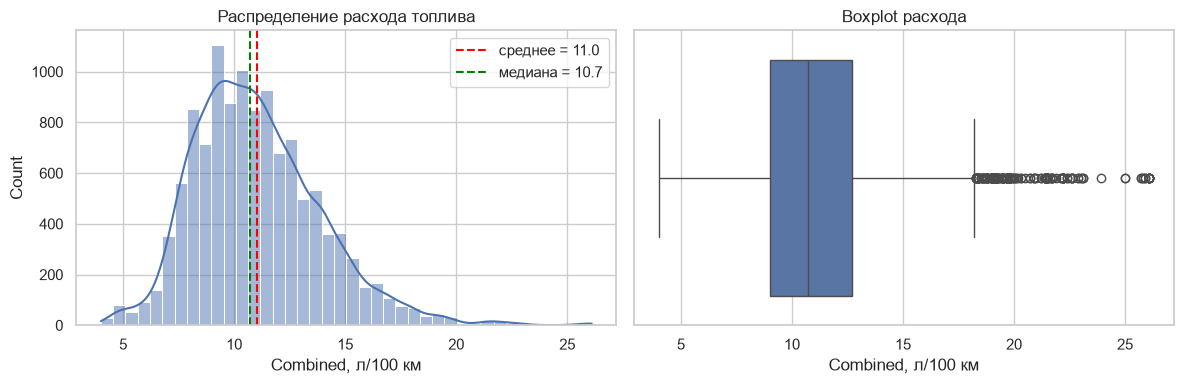

count    11828.00
mean        11.03
std          2.88
min          4.00
25%          9.00
50%         10.70
75%         12.70
max         26.10
Name: Combined (L/100 km), dtype: float64
Асимметрия (skew): 0.81


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[TARGET], bins=40, kde=True, ax=axes[0])
axes[0].axvline(df[TARGET].mean(), color="red", linestyle="--", label=f"среднее = {df[TARGET].mean():.1f}")
axes[0].axvline(df[TARGET].median(), color="green", linestyle="--", label=f"медиана = {df[TARGET].median():.1f}")
axes[0].set_title("Распределение расхода топлива")
axes[0].set_xlabel("Combined, л/100 км")
axes[0].legend()

sns.boxplot(x=df[TARGET], ax=axes[1])
axes[1].set_title("Boxplot расхода")
axes[1].set_xlabel("Combined, л/100 км")

plt.tight_layout()
plt.show()

print(df[TARGET].describe().round(2))
print("Асимметрия (skew):", round(df[TARGET].skew(), 2))

**Вывод:**
- Распределение скошено вправо (skew 0.81): большинство машин расходует 9-12.7 л/100 км (25% и 75% квантили), правый хвост тянется до 26.1.
- Среднее 11.03 больше медианы 10.7 из-за хвоста. Std 2.88.
- Точки справа на boxplot это реальные мощные машины (V8, V12, фургоны), не ошибки, поэтому не удаляем.
- Для моделей: baseline «предсказать среднее» даст ошибку порядка std (около 2.9). Хвост означает, что сильнее всего модели будут ошибаться на редких тяжёлых машинах.

### 4.2 Объём двигателя и расход

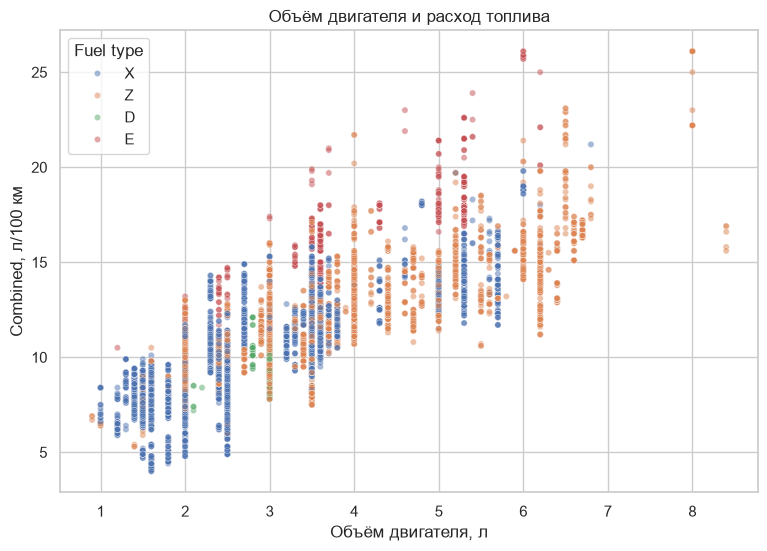

Корреляция Engine size и target: 0.811


In [21]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df, x="Engine size (L)", y=TARGET,
    hue="Fuel type", hue_order=["X", "Z", "D", "E"],
    alpha=0.5, s=20
)
plt.title("Объём двигателя и расход топлива")
plt.xlabel("Объём двигателя, л")
plt.ylabel("Combined, л/100 км")
plt.show()

print("Корреляция Engine size и target:", round(df["Engine size (L)"].corr(df[TARGET]), 3))

**Вывод:**
- Связь сильная положительная, корреляция 0.81: больше двигатель, выше расход.
- При одном и том же объёме разброс большой (гибриды внизу, тяжёлые внедорожники вверху), значит одного объёма недостаточно, нужны класс автомобиля и тип топлива.
- Точки `E` (этанол E85) лежат выше остальных при том же объёме: это эффект топлива, а не двигателя.
- Для моделей: Linear Regression поймает общий тренд, Decision Tree и KNN лучше справятся с нелинейностью и влиянием `Fuel type`.

### 4.3 Корреляционная матрица

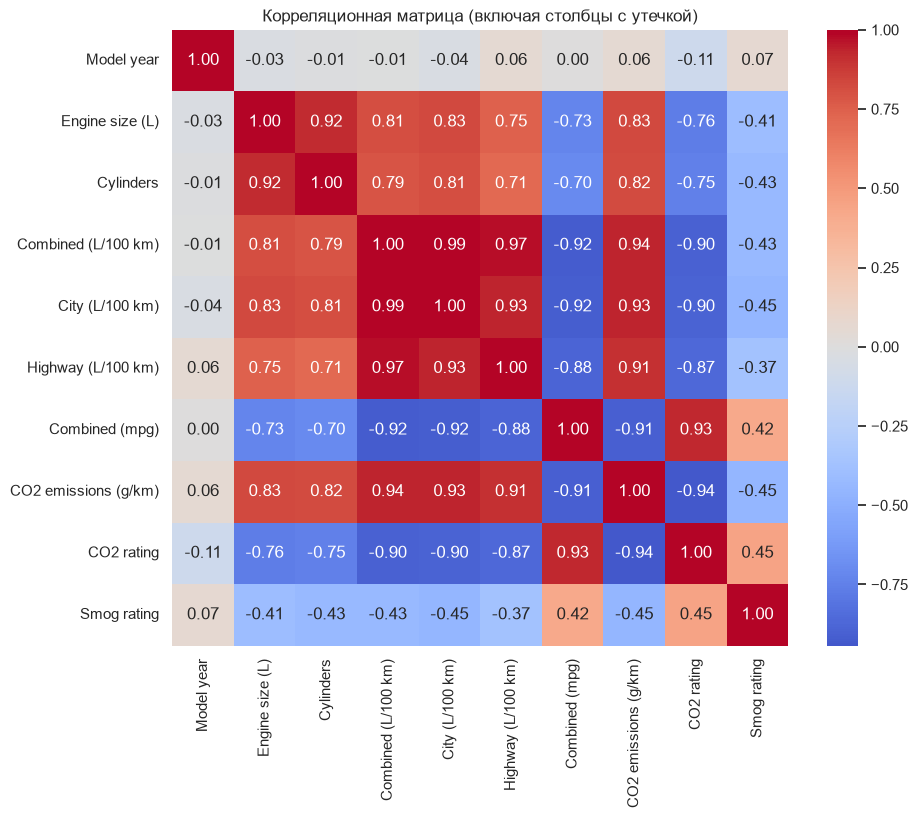

City (L/100 km)         0.992
Highway (L/100 km)      0.971
CO2 emissions (g/km)    0.939
Combined (mpg)         -0.922
CO2 rating             -0.902
Engine size (L)         0.811
Cylinders               0.789
Smog rating            -0.431
Model year             -0.006
Name: Combined (L/100 km), dtype: float64


In [22]:
num_cols = [
    "Model year", "Engine size (L)", "Cylinders", TARGET,
    "City (L/100 km)", "Highway (L/100 km)", "Combined (mpg)",
    "CO2 emissions (g/km)", "CO2 rating", "Smog rating",
]
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Корреляционная матрица (включая столбцы с утечкой)")
plt.show()

print(corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).round(3))

**Вывод:**
- Столбцы из `leak_cols` почти идеально связаны с target: `City` 0.99, `Highway` 0.97, `CO2 emissions` 0.94, `Combined (mpg)` -0.92, `CO2 rating` -0.90. Они выражают target напрямую, поэтому исключаем их из признаков. `Smog rating` связан слабее (-0.43), его тоже исключаем (правило проекта, пропуски).
- Из допустимых признаков самые сильные: `Engine size` (0.81) и `Cylinders` (0.79).
- `Model year` почти не связан с target (-0.01).
- `Engine size` и `Cylinders` сильно коррелируют друг с другом (мультиколлинеарность): для деревьев и KNN не проблема, для Linear Regression учитываем при интерпретации коэффициентов.

### 4.4 Цилиндры и тип топлива

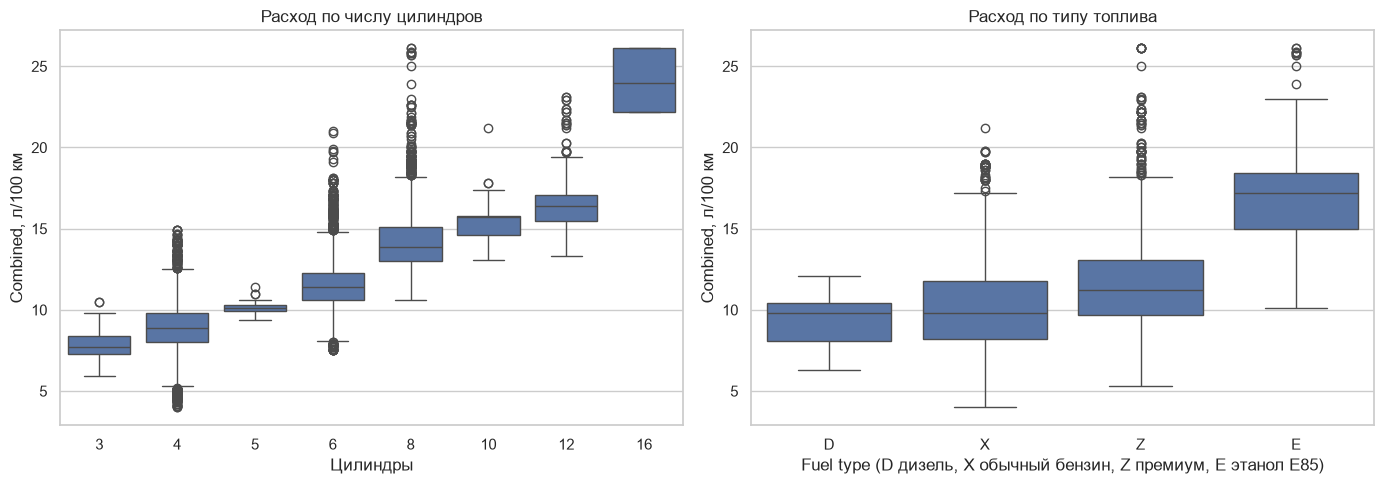

           count   mean
Cylinders              
3            197   7.74
4           5156   8.91
5             28  10.19
6           3835  11.58
8           2283  14.35
10            72  15.42
12           243  16.60
16            14  24.13
           count   mean
Fuel type              
D            272   9.31
E            423  16.97
X           5574  10.08
Z           5559  11.61


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Cylinders", y=TARGET, ax=axes[0])
axes[0].set_title("Расход по числу цилиндров")
axes[0].set_xlabel("Цилиндры")
axes[0].set_ylabel("Combined, л/100 км")

sns.boxplot(data=df, x="Fuel type", y=TARGET, order=["D", "X", "Z", "E"], ax=axes[1])
axes[1].set_title("Расход по типу топлива")
axes[1].set_xlabel("Fuel type (D дизель, X обычный бензин, Z премиум, E этанол E85)")
axes[1].set_ylabel("Combined, л/100 км")

plt.tight_layout()
plt.show()

print(df.groupby("Cylinders")[TARGET].agg(["count", "mean"]).round(2))
print(df.groupby("Fuel type")[TARGET].agg(["count", "mean"]).round(2))

**Вывод:**
- Расход растёт с числом цилиндров: в среднем 3 цил. 7.7, 4 цил. 8.9, 6 цил. 11.6, 8 цил. 14.4, 12 цил. 16.6 л/100 км.
- Группы очень разного размера: 4 цил. 5156 машин, 6 цил. 3835, 8 цил. 2283, а 5 цил. всего 28, 10 цил. 72, 16 цил. 14. В редких группах оценки менее надёжны, там ждём бóльших ошибок.
- Тип топлива сильно сдвигает расход: E 17.0, Z 11.6, X 10.1, D 9.3.
- Внутри групп разброс остаётся, значит нужны ещё класс и трансмиссия.
- Для моделей: `Fuel type` кодируем one-hot, `Cylinders` можно оставить числовым.

### 4.5 Годы и класс автомобиля

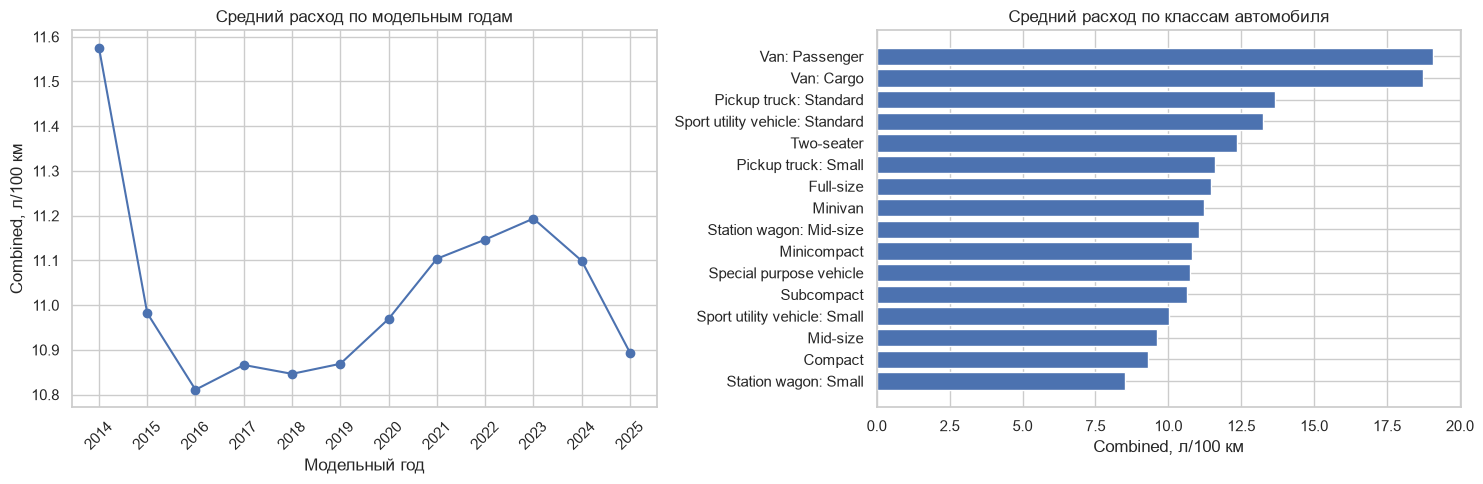

Model year
2014    11.58
2015    10.98
2016    10.81
2017    10.87
2018    10.85
2019    10.87
2020    10.97
2021    11.10
2022    11.15
2023    11.19
2024    11.10
2025    10.89
Name: Combined (L/100 km), dtype: float64
Vehicle class
Station wagon: Small                8.51
Compact                             9.29
Mid-size                            9.62
Sport utility vehicle: Small       10.02
Subcompact                         10.65
Special purpose vehicle            10.75
Minicompact                        10.82
Station wagon: Mid-size            11.06
Minivan                            11.23
Full-size                          11.45
Pickup truck: Small                11.60
Two-seater                         12.36
Sport utility vehicle: Standard    13.25
Pickup truck: Standard             13.65
Van: Cargo                         18.72
Van: Passenger                     19.08
Name: Combined (L/100 km), dtype: float64


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

yearly = df.groupby("Model year")[TARGET].mean()
axes[0].plot(yearly.index, yearly.values, marker="o")
axes[0].set_title("Средний расход по модельным годам")
axes[0].set_xlabel("Модельный год")
axes[0].set_ylabel("Combined, л/100 км")
axes[0].set_xticks(yearly.index)
axes[0].tick_params(axis="x", rotation=45)

by_class = df.groupby("Vehicle class")[TARGET].mean().sort_values()
axes[1].barh(by_class.index, by_class.values)
axes[1].set_title("Средний расход по классам автомобиля")
axes[1].set_xlabel("Combined, л/100 км")

plt.tight_layout()
plt.show()

print(yearly.round(2))
print(by_class.round(2))

**Вывод:**
- По годам: 2014 выделяется (11.58), с 2015 по 2025 расход почти не меняется (10.8-11.2). Повышение экономичности двигателей компенсируется ростом доли тяжёлых внедорожников и пикапов, поэтому корреляция с годом около нуля.
- Класс сильно влияет: самые экономичные `Station wagon: Small` (8.5), `Compact` (9.3), `Mid-size` (9.6); самые затратные `SUV: Standard` (13.3), `Pickup truck: Standard` (13.7), `Van: Cargo` (18.7), `Van: Passenger` (19.1).
- Фургоны редкие (22 и 70 машин), там возможны крупные ошибки.
- Для моделей: `Vehicle class` важный признак, кодируем one-hot. Ценность `Model year` решим при отборе признаков. Для group split помним, что одна модель повторяется в разные годы.

## Итог этапа 4

- **Target:** скошен вправо (среднее 11.03, медиана 10.7, std 2.88),
  мощный хвост до 26.1.
- **Сильные признаки:** `Engine size` (0.81), `Cylinders` (0.79),
  `Fuel type`, `Vehicle class`.
- **Слабый признак:** `Model year` (-0.01).
- **Leakage подтверждено:** 5 столбцов из `leak_cols` коррелируют с
  target на 0.90-0.99, исключаем при сборке признаков.
- **Мультиколлинеарность:** `Engine size` и `Cylinders`.
- **Редкие группы:** 5, 10 и 16 цилиндров; `Van: Cargo`,
  `Van: Passenger`.
- **Для этапа 5:** one-hot для `Fuel type` и `Vehicle class`, разбор
  `Transmission` на тип и число передач, новые признаки (тип
  трансмиссии, число передач, объём на цилиндр). Масштабирование не
  используем.

## Этап 5. Feature engineering

Готовим признаки: разбираем `Transmission`, добавляем новый признак,
настраиваем кодирование и пропуски, фиксируем итоговый набор.
Масштабирование не используем.

Разбор кода трансмиссии и деление двух столбцов считаем по одной
строке и сразу. Медиану и one-hot только описываем: они учатся на
данных, поэтому `fit` будет внутри pipeline на train. Масштабирование
в проекте не используем: по требованию проекта все модели работают на
исходных единицах. Поэтому препроцессор по сути один
(`preprocessor_base`), а `preprocessor_knn` - его псевдоним для KNN.


## 5.1 Новые признаки

**Что делаем:** из `Transmission` берём тип (`trans_type`) и число передач (`gears`), добавляем `disp_per_cyl` (объём двигателя / число цилиндров).

**Зачем:**
- В `Transmission` 28 кодов, часть из них редкие (`AS4`: 2 строки, `AM5`: 4). После разбора остаётся 5 типов и одно число.
- В данных нет веса и мощности, поэтому `disp_per_cyl` частично их заменяет: двигатели с одинаковым числом цилиндров, но разным объёмом получают разные значения.

In [25]:
tr = df["Transmission"].str.extract(r"^([A-Z]+)(\d*)$")
df["trans_type"] = tr[0]
df["gears"] = pd.to_numeric(tr[1], errors="coerce")

df["disp_per_cyl"] = df["Engine size (L)"] / df["Cylinders"]

print(df["trans_type"].value_counts())
print("Пропусков в gears:", df["gears"].isna().sum())
print(df.groupby("trans_type")[TARGET].mean().round(2))
print(df[["disp_per_cyl", "gears"]].corrwith(df[TARGET]).round(3))

trans_type
AS    4911
A     3032
M     1570
AM    1270
AV    1045
Name: count, dtype: int64
Пропусков в gears: 507
trans_type
A     12.44
AM    10.93
AS    11.20
AV     7.71
M     10.06
Name: Combined (L/100 km), dtype: float64
disp_per_cyl    0.524
gears           0.165
dtype: float64


**Результат:**
- Типы трансмиссии: `AS` 4911, `A` 3032, `M` 1570, `AM` 1270, `AV` 1045.
- Пропуски в `gears` только у `AV` (вариатор), 507 строк: у вариатора нет фиксированных передач, это не ошибка данных.
- Средний расход: `AV` 7.7, `M` 10.1, `AM` 10.9, `AS` 11.2, `A` 12.4 л/100 км.
- Корреляция с target: `disp_per_cyl` 0.52, `gears` 0.17.

**Вывод:** `trans_type` заметно различает расход, у `disp_per_cyl` связь с target заметная (0.52). `gears` связан слабее, но описывает трансмиссию иначе, чем тип.

**Решение:** оставляем все три признака. Пропуски в `gears` не заполняем здесь.
**Причина:** медиана считается по данным, значит заполнять её нужно только на train, внутри pipeline. То, что это вариатор, не теряется: оно хранится в `trans_type`.

## 5.2 Кодирование и пропуски

**Что делаем:** описываем препроцессор без `fit`: заполнение пропусков
и one-hot кодирование. Масштабирование не используем.

**Зачем:**

- Масштабирование не используется по требованию проекта. Linear
  Regression и Decision Tree к нему нечувствительны, а KNN работает на
  исходных единицах.
- Кодирование нужно всем категориальным столбцам `Vehicle class`,
  `Fuel type`, `trans_type`: у них нет порядка, поэтому one-hot, а не
  числа 1, 2, 3.
- Пропуски в `gears` (507, вариатор) заполняем медианой, потому что
  модели с пропусками не работают.
- `handle_unknown="ignore"` нужен из-за редких категорий (3.3): если
  категория окажется только в test, кодировщик не упадёт.

**Ограничение для KNN:** без масштаба расстояния определяются
признаками с большим числовым размахом (`Cylinders` 3-16, `gears`,
`Model year` 2014-2025), а one-hot столбцы (0/1) почти не влияют. Это
проверяем в 7.6 (KNN с `Model year` и без).

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

num_cols = ["Model year", "Engine size (L)", "Cylinders", "disp_per_cyl", "gears"]
cat_cols = ["Vehicle class", "Fuel type", "trans_type"]

# Один препроцессор для всех моделей: пропуски + one-hot, БЕЗ масштабирования
preprocessor_base = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

# KNN работает на тех же исходных единицах (масштабирование не используем)
preprocessor_knn = preprocessor_base

**Результат:** препроцессор создан, данные он пока не видел.

**Решение:** масштабирование не используем нигде. `preprocessor_knn`
совпадает с `preprocessor_base`, отдельное имя остаётся только для
читаемости кода на этапе 7.

**Причина:** требование проекта. Всё, что учится на данных (медиана,
список категорий), обучается на train внутри pipeline.

## 5.3 Отбор признаков

**Что делаем:** собираем `X` и `y` и проверяем, что столбцов из `leak_cols` в `X` нет.

**Зачем:** в 3.7 мы обещали убрать их при сборке признаков. `assert` остановит ноутбук, если утечка туда попадёт.

In [27]:
X = df[num_cols + cat_cols]
y = df[TARGET]

assert not set(leak_cols) & set(X.columns)
assert TARGET not in X.columns
print("X:", X.shape, "| y:", y.shape)
print("Категорий: Vehicle class", X["Vehicle class"].nunique(),
      "| Fuel type", X["Fuel type"].nunique(),
      "| trans_type", X["trans_type"].nunique())
print("Пропуски:", X.isna().sum()[X.isna().sum() > 0].to_dict())

X: (11828, 8) | y: (11828,)
Категорий: Vehicle class 16 | Fuel type 4 | trans_type 5
Пропуски: {'gears': 507}


**Результат:**
- `X`: (11828, 8), `y`: (11828,). Размеры совпадают.
- Категорий: `Vehicle class` 16, `Fuel type` 4, `trans_type` 5. После one-hot получается 25 столбцов, это немного.
- Пропуски только в `gears` (507, вариаторы), заполним в pipeline.
- Столбцы из `leak_cols` и target в `X` отсутствуют (проверено через `assert`).

**Решение:** 8 признаков: 5 числовых и 3 категориальных.
**Причина:** берём характеристики машины, которые описывают двигатель, трансмиссию, топливо и размер. `Make` (44 значения) и `Model` (2269 названий) не берём: one-hot раздул бы число столбцов и размыл расстояния в KNN. `Model year` оставляем условно (связь с target около нуля), проверим на этапе 7 сравнением MAE с годом и без него.

# Этап 6. Split и защита от утечки

Делим данные на train, validation и test. Test трогаем один раз, в самом конце.

## 6.1 Почему group split

В данных одна и та же модель встречается в разные годы (в среднем 5 строк на пару `Make` + `Model`), и её характеристики почти не меняются. При обычном случайном split такая машина попадёт и в train, и в test, и модель получит почти готовый ответ. Поэтому делим по группам: все строки одной пары `Make` + `Model` целиком попадают в одну часть.

**Про stratify:** стратификация нужна для классификации, у нас регрессия, поэтому её не используем. Вместо этого проверим, что распределение target в частях похоже.

**Пропорции:** train 70%, validation 15%, test 15%. Validation нужна для выбора модели и признаков (например, нужен ли `Model year`), test только для финальной оценки.

### 1. Split

In [28]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold

RANDOM_STATE = 42
groups = df["Make"] + " | " + df["Model"].str.strip()

# Шаг 1: отделяем test (15%)
split1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
temp_idx, test_idx = next(split1.split(X, y, groups))
X_temp, y_temp, g_temp = X.iloc[temp_idx], y.iloc[temp_idx], groups.iloc[temp_idx]
X_test, y_test, g_test = X.iloc[test_idx], y.iloc[test_idx], groups.iloc[test_idx]

# Шаг 2: из остатка отделяем validation (15% от всех данных)
split2 = GroupShuffleSplit(n_splits=1, test_size=0.15 / 0.85, random_state=RANDOM_STATE)
train_idx, val_idx = next(split2.split(X_temp, y_temp, g_temp))
X_train, y_train, g_train = X_temp.iloc[train_idx], y_temp.iloc[train_idx], g_temp.iloc[train_idx]
X_val, y_val, g_val = X_temp.iloc[val_idx], y_temp.iloc[val_idx], g_temp.iloc[val_idx]

print("train:", len(X_train), "| val:", len(X_val), "| test:", len(X_test))

train: 8268 | val: 1809 | test: 1751


### 2. проверка утечки

In [29]:
# Есть ли одинаковые группы в разных частях? Должно быть 0
print("train и val:", len(set(g_train) & set(g_val)))
print("train и test:", len(set(g_train) & set(g_test)))
print("val и test:", len(set(g_val) & set(g_test)))

# Среднее значение target в каждой части. Должно быть похоже
print("Среднее target: train", round(y_train.mean(), 2),
      "| val", round(y_val.mean(), 2),
      "| test", round(y_test.mean(), 2))

train и val: 0
train и test: 0
val и test: 0
Среднее target: train 11.03 | val 10.98 | test 11.07


### 3. сравнение с обычным split

In [30]:
from sklearn.model_selection import train_test_split

# Обычный случайный split, для сравнения
g_a, g_b = train_test_split(groups, test_size=0.15, random_state=42)

# Какая доля строк test имеет такую же модель в train
print("Обычный split:", round(g_b.isin(g_a).mean() * 100, 1), "%")
print("Group split:", round(g_test.isin(g_train).mean() * 100, 1), "%")

Обычный split: 94.7 %
Group split: 0.0 %


**Результат:**
- Train 8268 строк (69.9%, 1587 групп), validation 1809 (15.3%, 341 группа), test 1751 (14.8%, 341 группа).
- Пересечений групп между частями нет (0, 0, 0).
- Target в частях похож: среднее 11.03 (train), 10.98 (val), 11.07 (test), std 2.94, 2.66, 2.83.
- При случайном split 94.7% строк test имели бы «двойника» в train, при group split 0%. Это показывает, что обычный split дал бы завышенное качество.
- Все категории `Vehicle class`, `Fuel type`, `trans_type` из val и test есть в train. Незначительно: `Van: Passenger` отсутствует в validation.

**Как избегаем leakage:**

1. Группы по `Make` + `Model`: одна модель не бывает одновременно в
   train и в test.
2. Из признаков убраны 6 столбцов, выражающих target (этап 3.7, 5.3).
3. Split сделан до любого `fit`: медиана и one-hot будут обучаться
   только на train внутри pipeline.
4. Validation используем для выбора модели и признаков, test только
   для финальной оценки.
5. Cross-validation делаем только на train и тоже по группам
   (`GroupKFold`).

**Решение:** `RANDOM_STATE = 42` фиксирует разбиение, чтобы результаты
воспроизводились. 
**Ограничение:** split случайный по группам, поэтому
состав test зависит от `RANDOM_STATE`. Распределение `Vehicle class` в
частях немного отличается (например, `Pickup truck: Small` 1.4% в
train и 4.8% в test), это учтём в error analysis.

## Итог этапа 6

- **Split:** train 70% / validation 15% / test 15% по группам
  `Make` + `Model`.
- **Утечек между частями нет:** группы не пересекаются.
- **CV:** `GroupKFold(5)` на train (создаётся в 7.5).
- **Передаём на этап 7:** `X_train`, `y_train`, `X_val`, `y_val`,
  `X_test`, `y_test`, `g_train`, `g_val`, `g_test`,
  `preprocessor_base`, `preprocessor_knn`.

In [31]:
needed = ["df", "X", "y", "num_cols", "cat_cols", "preprocessor_base", "preprocessor_knn",
          "X_train", "y_train", "X_val", "y_val", "X_test", "y_test",
          "g_train", "g_val", "g_test"]
missing = [n for n in needed if n not in globals()]
assert not missing, f"Сначала выполните этапы 5 и 6. Не найдено: {missing}"
print("Всё на месте")

Всё на месте


## Этап 7. Baseline и модели

Все модели сравниваем на **validation**. Test используем один раз, в
конце. Каждая модель обучается внутри `Pipeline`, поэтому медиана и
one-hot считаются только на train. Масштабирование не используем.
Метрики: MAE (основная), RMSE, R².

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

results = {}   # сюда складываем метрики на validation

## 7.1 Baseline: среднее значение target

**Идея:** модель, которая для любой машины предсказывает среднее
train. Это «пол»: любая осмысленная модель должна быть заметно лучше.
**Что ожидаем:** R² около 0, RMSE порядка std target (около 2,7
л/100 км).

**Результат:** MAE = 2.123, RMSE = 2.663, R² = -0.000 (на validation).
**Вывод:** это точка отсчёта для критерия успеха: MAE лучшей модели
должен быть минимум вдвое ниже, то есть не больше 1.06.

In [33]:
dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)
results["Mean baseline"] = evaluate(y_val, dummy.predict(X_val))
pd.DataFrame(results).T.round(3)

,MAE,RMSE,R2
Mean baseline,2.123,2.663,-0.0


## 7.2 Linear Regression

**Идея:** ищем линейную зависимость расхода от объёма двигателя,
цилиндров, типа топлива и т. д. **Препроцессор:** `preprocessor_base`
(заполнение пропусков в `gears` медианой + one-hot). Масштабирование
не используем.

**Результат:** MAE = 0.802, RMSE = 1.074, R² = 0.837. **Вывод:** ошибка
в 2,6 раза ниже baseline (2.123), критерий по MAE уже выполнен. Но
линейная модель слабее дерева и KNN. Вероятно, ей не хватает
нелинейности: расход растёт с объёмом и числом цилиндров не по прямой,
а эффект типа топлива и класса зависит от размера двигателя.

In [34]:
lin = Pipeline([("prep", preprocessor_base), ("model", LinearRegression())])
lin.fit(X_train, y_train)
results["Linear Regression"] = evaluate(y_val, lin.predict(X_val))
pd.DataFrame(results).T.round(3)

,MAE,RMSE,R2
Mean baseline,2.123,2.663,-0.000
Linear Regression,0.802,1.074,0.837


## 7.3 Decision Tree Regressor

**Идея:** дерево делит машины на группы по порогам (например «объём >
3 л») и в каждой группе предсказывает среднее. Умеет ловить
нелинейность. **Главный риск:** переобучение. Глубокое дерево
запоминает train. Чтобы это показать, сравниваем MAE на train и на
validation для разных `max_depth`.

**Результат:** лучшая глубина = `None` (MAE на validation = 0.662,
RMSE = 0.961, R² = 0.870). **Вывод:** с ростом глубины ошибка на train
падает до 0.314, а на validation замедляется. До глубины 5 кривые
почти совпадают (0.927 и 0.912), после глубины 8 train уходит вниз
быстрее. Выигрыш `None` над глубиной 16 крошечный (0.662 против
0.671), то есть кривая вышла на плато. Зазор между train (0.314) и
validation (0.662) остаётся большим, так что дерево переобучено. Но на
новых группах `Make + Model` оно всё равно лучше Linear Regression,
поэтому оставляем `max_depth=None`, а в плане на final проверим
ограничение через `min_samples_leaf`.

,max_depth,MAE_train,MAE_val
0,2,1.257,1.093
1,3,1.092,0.996
2,5,0.927,0.912
3,8,0.734,0.803
4,12,0.538,0.714
5,16,0.400,0.671
6,None,0.314,0.662


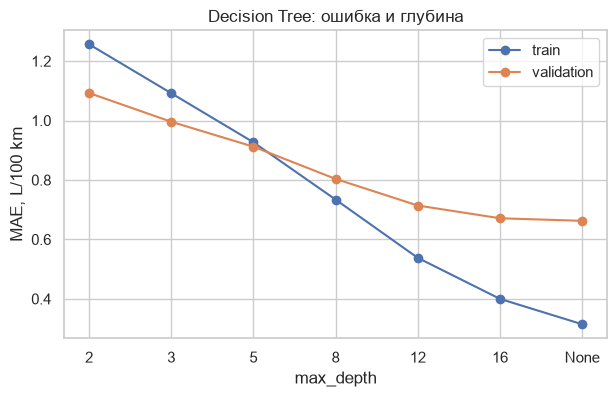

Лучшая глубина: None


,MAE,RMSE,R2
Mean baseline,2.123,2.663,-0.000
Linear Regression,0.802,1.074,0.837
Decision Tree,0.662,0.961,0.870


In [35]:
depths = [2, 3, 5, 8, 12, 16, None]
rows = []
for d in depths:
    m = Pipeline([("prep", preprocessor_base),
                  ("model", DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE))])
    m.fit(X_train, y_train)
    rows.append({
        "max_depth": str(d),
        "MAE_train": mean_absolute_error(y_train, m.predict(X_train)),
        "MAE_val": mean_absolute_error(y_val, m.predict(X_val)),
    })
tree_depth = pd.DataFrame(rows)
display(tree_depth.round(3))

plt.figure(figsize=(7, 4))
plt.plot(tree_depth["max_depth"], tree_depth["MAE_train"], marker="o", label="train")
plt.plot(tree_depth["max_depth"], tree_depth["MAE_val"], marker="o", label="validation")
plt.xlabel("max_depth"); plt.ylabel("MAE, L/100 km")
plt.title("Decision Tree: ошибка и глубина"); plt.legend(); plt.show()

best_depth = depths[tree_depth["MAE_val"].idxmin()]
print("Лучшая глубина:", best_depth)

tree = Pipeline([("prep", preprocessor_base),
                 ("model", DecisionTreeRegressor(max_depth=best_depth, random_state=RANDOM_STATE))])
tree.fit(X_train, y_train)
results["Decision Tree"] = evaluate(y_val, tree.predict(X_val))
pd.DataFrame(results).T.round(3)

## 7.4 KNN Regressor

**Идея:** для новой машины находим k самых похожих в train и берём
среднее их расхода. **Препроцессор:** `preprocessor_knn` (без
масштабирования, по требованию проекта). **Важно:** KNN считает
расстояния в исходных единицах, поэтому признаки с большим размахом
(`Cylinders`, `gears`, `Model year`) влияют сильнее, а one-hot столбцы
слабее. **Подбор k:** малое k даёт шумные предсказания
(переобучение), большое сглаживает слишком сильно.

**Результат:** лучшее k = 5 (MAE на validation = 0.746, RMSE = 1.037,
R² = 0.848). **Вывод:** при k=1 ошибка на train 0.359 (не ноль, потому
что у одинаковых по признакам машин расход немного разный), а на
validation 0.796. Минимум на validation при k=3-5 (0.748 и 0.746),
дальше ошибка растёт (0.882 при k=50), то есть сглаживание становится
слишком сильным. KNN лучше Linear Regression (0.802), но хуже Decision
Tree (0.662). Без масштабирования KNN заметно слабее: в пробном
запуске со `StandardScaler` MAE был 0.667. Это цена требования
проекта.

,k,MAE_train,MAE_val
0,1,0.359,0.796
1,3,0.474,0.748
2,5,0.539,0.746
3,10,0.652,0.791
4,15,0.729,0.803
5,20,0.782,0.816
6,30,0.854,0.837
7,50,0.937,0.882


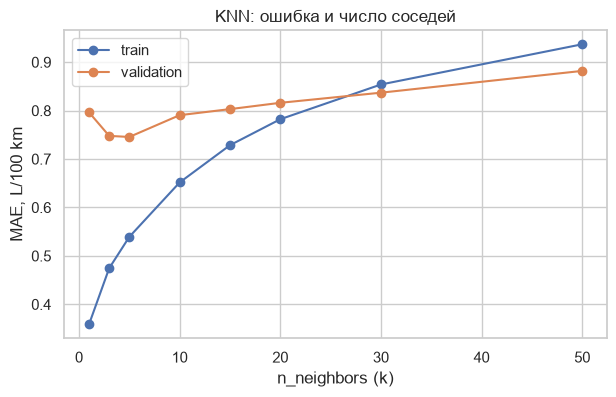

Лучшее k: 5


,MAE,RMSE,R2
Mean baseline,2.123,2.663,-0.000
Linear Regression,0.802,1.074,0.837
Decision Tree,0.662,0.961,0.870
KNN,0.746,1.037,0.848


In [36]:
ks = [1, 3, 5, 10, 15, 20, 30, 50]
rows = []
for k in ks:
    m = Pipeline([("prep", preprocessor_knn),
                  ("model", KNeighborsRegressor(n_neighbors=k))])
    m.fit(X_train, y_train)
    rows.append({
        "k": k,
        "MAE_train": mean_absolute_error(y_train, m.predict(X_train)),
        "MAE_val": mean_absolute_error(y_val, m.predict(X_val)),
    })
knn_k = pd.DataFrame(rows)
display(knn_k.round(3))

plt.figure(figsize=(7, 4))
plt.plot(knn_k["k"], knn_k["MAE_train"], marker="o", label="train")
plt.plot(knn_k["k"], knn_k["MAE_val"], marker="o", label="validation")
plt.xlabel("n_neighbors (k)"); plt.ylabel("MAE, L/100 km")
plt.title("KNN: ошибка и число соседей"); plt.legend(); plt.show()

best_k = int(knn_k.loc[knn_k["MAE_val"].idxmin(), "k"])
print("Лучшее k:", best_k)

knn = Pipeline([("prep", preprocessor_knn),
                ("model", KNeighborsRegressor(n_neighbors=best_k))])
knn.fit(X_train, y_train)
results["KNN"] = evaluate(y_val, knn.predict(X_val))
pd.DataFrame(results).T.round(3)

**Идея:** для новой машины находим k самых похожих в train и берём
среднее их расхода. **Препроцессор:** `preprocessor_knn` (без
масштабирования, по требованию проекта). **Важно:** KNN считает
расстояния в исходных единицах, поэтому признаки с большим размахом
(`Cylinders`, `gears`, `Model year`) влияют сильнее, а one-hot столбцы
слабее. **Подбор k:** малое k даёт шумные предсказания
(переобучение), большое сглаживает слишком сильно.

**Результат:** лучшее k = 5 (MAE на validation = 0.746, RMSE = 1.037,
R² = 0.848). **Вывод:** при k=1 ошибка на train 0.359 (не ноль, потому
что у одинаковых по признакам машин расход немного разный), а на
validation 0.796. Минимум на validation при k=3-5 (0.748 и 0.746),
дальше ошибка растёт (0.882 при k=50), то есть сглаживание становится
слишком сильным. KNN лучше Linear Regression (0.802), но хуже Decision
Tree (0.662). Без масштабирования KNN заметно слабее: в пробном
запуске со `StandardScaler` MAE был 0.667. Это цена требования
проекта.

## 7.5 Cross-validation (GroupKFold, 5 фолдов)

**Зачем:** результат на одном validation может быть случайным. CV
проверяет модель на 5 разных разбиениях train. **Почему GroupKFold:**
группы `Make + Model` не пересекаются между фолдами, поэтому утечки
«почти одинаковых машин» нет, как и в основном split. Test в CV не
участвует.

**Результат:** см. таблицу (среднее и std по фолдам).

| Модель | MAE (среднее ± std) | R² (среднее) |
|---|---|---|
| Decision Tree | 0.703 ± 0.026 | 0.873 |
| KNN | 0.790 ± 0.031 | 0.862 |
| Linear Regression | 0.878 ± 0.027 | 0.839 |

**Вывод:** порядок моделей совпадает с validation: Decision Tree
лучше KNN, а KNN лучше Linear Regression. Std составляет около 4% от
среднего MAE, а разрыв между моделями (0.09-0.17) заметно больше std,
поэтому порядок устойчив. CV-ошибка выше, чем на validation (0.703
против 0.662 у дерева): на одном validation нам немного повезло с
составом групп, и CV даёт более честную оценку.

In [37]:
from sklearn.model_selection import GroupKFold

cv = GroupKFold(n_splits=5)   # группы Make + Model не пересекаются между фолдами

models = {
    "Linear Regression": Pipeline([("prep", preprocessor_base), ("model", LinearRegression())]),
    "Decision Tree": Pipeline([("prep", preprocessor_base),
                               ("model", DecisionTreeRegressor(max_depth=best_depth, random_state=RANDOM_STATE))]),
    "KNN": Pipeline([("prep", preprocessor_knn),
                     ("model", KNeighborsRegressor(n_neighbors=best_k))]),
}
scoring = {"mae": "neg_mean_absolute_error",
           "rmse": "neg_root_mean_squared_error",
           "r2": "r2"}

cv_rows = []
for name, model in models.items():
    s = cross_validate(model, X_train, y_train, cv=cv, groups=g_train, scoring=scoring)
    cv_rows.append({
        "model": name,
        "MAE_mean": -s["test_mae"].mean(), "MAE_std": s["test_mae"].std(),
        "RMSE_mean": -s["test_rmse"].mean(),
        "R2_mean": s["test_r2"].mean(), "R2_std": s["test_r2"].std(),
    })
cv_table = pd.DataFrame(cv_rows).set_index("model")
cv_table.round(3)

,MAE_mean,MAE_std,RMSE_mean,R2_mean,R2_std
model,,,,,
Linear Regression,0.878,0.027,1.175,0.839,0.012
Decision Tree,0.703,0.026,1.042,0.873,0.016
KNN,0.790,0.031,1.087,0.862,0.013


## 7.6 Проверка признака Model year

На этапе 5 мы оставили `Model year` условно: корреляция с target около
нуля (-0.01). Для KNN без масштаба этот признак особенно подозрителен,
потому что его размах (2014-2025) искажает расстояния. **Проверка:**
сравниваем MAE на validation с этим признаком и без него для всех трёх
моделей.

**Результат:** Decision Tree: 0.662 с годом и 0.674 без. Linear
Regression: 0.802 и 0.801 (разницы нет). KNN: 0.746 с годом и 0.715
без.

**Решение:** оставляем `Model year` (`USE_YEAR = True`). Для лучшей
модели (Decision Tree) признак даёт небольшой выигрыш (0.012), а для
линейной модели он ничего не меняет. Для KNN без масштаба год вредит
(0.031), потому что его размах 2014-2025 искажает расстояния. Но
разница для дерева меньше std в CV (0.026), поэтому выигрыш скромный.
Единый набор признаков для всех моделей проще и честнее при
сравнении. Вариант KNN без года отмечаем в плане на final.

In [38]:
def build_preps(num_list):
    base = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), num_list),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])
    knn_p = base   # без масштабирования
    return base, knn_p

def make_models(num_list, depth, k):
    base, knn_p = build_preps(num_list)
    return {
        "Linear Regression": Pipeline([("prep", base), ("model", LinearRegression())]),
        "Decision Tree": Pipeline([("prep", base), ("model", DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE))]),
        "KNN": Pipeline([("prep", knn_p), ("model", KNeighborsRegressor(n_neighbors=k))]),
    }

num_with_year = list(num_cols)                        # как на этапе 5
num_no_year = [c for c in num_cols if c != "Model year"]

rows = []
for label, nl in [("с Model year", num_with_year), ("без Model year", num_no_year)]:
    for name, m in make_models(nl, best_depth, best_k).items():
        m.fit(X_train, y_train)
        rows.append({"model": name, "вариант": label,
                     "MAE_val": mean_absolute_error(y_val, m.predict(X_val))})
year_check = pd.DataFrame(rows).pivot(index="model", columns="вариант", values="MAE_val")
year_check.round(3)

вариант,без Model year,с Model year
model,,
Decision Tree,0.674,0.662
KNN,0.715,0.746
Linear Regression,0.801,0.802


На этапе 5 мы оставили `Model year` условно: корреляция с target около
нуля (-0.01). Для KNN без масштаба этот признак особенно подозрителен,
потому что его размах (2014-2025) искажает расстояния. **Проверка:**
сравниваем MAE на validation с этим признаком и без него для всех трёх
моделей.

**Результат:** Decision Tree: 0.662 с годом и 0.674 без. Linear
Regression: 0.802 и 0.801 (разницы нет). KNN: 0.746 с годом и 0.715
без.

**Решение:** оставляем `Model year` (`USE_YEAR = True`). Для лучшей
модели (Decision Tree) признак даёт небольшой выигрыш (0.012), а для
линейной модели он ничего не меняет. Для KNN без масштаба год вредит
(0.031), потому что его размах 2014-2025 искажает расстояния. Но
разница для дерева меньше std в CV (0.026), поэтому выигрыш скромный.
Единый набор признаков для всех моделей проще и честнее при
сравнении. Вариант KNN без года отмечаем в плане на final.

## 7.7 Финальная оценка на test

**Порядок:** гиперпараметры и набор признаков уже выбраны на
validation и CV. Теперь обучаем каждую модель на train + validation
(больше данных) и **один раз** считаем метрики на test. Решения после
этого не меняем.

**Результат:** см. таблицу.

| Модель | MAE | RMSE | R² |
|---|---|---|---|
| Mean baseline | 2.211 | 2.835 | -0.000 |
| Linear Regression | 0.780 | 1.028 | 0.868 |
| Decision Tree | 0.615 | 0.890 | 0.901 |
| KNN | 0.715 | 0.973 | 0.882 |

**Критерий успеха:** MAE лучшей модели минимум вдвое ниже baseline,
R² ≥ 0,8 → **выполнен**. MAE Decision Tree 0.615 против 2.211 у
baseline (в 3.59 раза ниже, нужно ≥ 2), R² = 0.901 (нужно ≥ 0.8).

**Вывод:** лучшая модель Decision Tree, затем KNN и Linear Regression.
Порядок тот же, что на validation и в CV, значит выбор модели не
случаен. MAE на test (0.615) ниже, чем в CV (0.703): часть выигрыша
даёт дообучение на train + validation, часть, вероятно, состав
test-групп. Поэтому опираться стоит на оба числа.

In [39]:
USE_YEAR = True   # поставьте False, если по шагу 6 решили убрать Model year
final_num = num_with_year if USE_YEAR else num_no_year

X_trval = pd.concat([X_train, X_val])
y_trval = pd.concat([y_train, y_val])

final_models = make_models(final_num, best_depth, best_k)
test_results = {}

d_final = DummyRegressor(strategy="mean").fit(X_trval, y_trval)
test_results["Mean baseline"] = evaluate(y_test, d_final.predict(X_test))

test_preds = {}
for name, m in final_models.items():
    m.fit(X_trval, y_trval)
    test_preds[name] = m.predict(X_test)
    test_results[name] = evaluate(y_test, test_preds[name])

test_table = pd.DataFrame(test_results).T
display(test_table.round(3))

best_name = test_table.drop("Mean baseline")["MAE"].idxmin()
ratio = test_table.loc["Mean baseline", "MAE"] / test_table.loc[best_name, "MAE"]
print(f"Лучшая модель: {best_name}")
print(f"MAE baseline / MAE лучшей = {ratio:.2f}  (нужно ≥ 2)")
print(f"R² лучшей = {test_table.loc[best_name, 'R2']:.3f}  (нужно ≥ 0.8)")

,MAE,RMSE,R2
Mean baseline,2.211,2.835,-0.000
Linear Regression,0.780,1.028,0.868
Decision Tree,0.615,0.890,0.901
KNN,0.715,0.973,0.882


Лучшая модель: Decision Tree
MAE baseline / MAE лучшей = 3.59  (нужно ≥ 2)
R² лучшей = 0.901  (нужно ≥ 0.8)


## 7.8 Error analysis

Смотрим, где лучшая модель (Decision Tree) ошибается сильнее всего, по
срезам: класс автомобиля, тип топлива, число цилиндров, гибриды. На
графиках точки лежат вдоль диагонали, а ошибки распределены симметрично
вокруг нуля и в основном укладываются в ±1 л/100 км. Тяжёлые хвосты
доходят до ±4 л/100 км.

**Находки:**

1. **Гибриды (самый сильный эффект).** MAE у гибридов 1.03 при
   смещении +0.96, у остальных 0.60 и -0.04. В test всего 45 гибридов
   из 1751 (2,6%). Модель завышает им расход примерно на 1 л/100 км,
   потому что признака «гибрид» в наборе нет: она видит только объём и
   класс, а двигатель обычного и гибридного авто может быть одинаковым.
2. **Мощные и «заряженные» версии.** В топ-10 ошибок шесть строк
   занимают Chevrolet Camaro ZL1 (6.2 л, истинный расход 15.4-16.8,
   прогноз 11.7-12.8) и Mitsubishi Lancer Evolution (2.0 л, истинный
   12.3, прогноз 8.3-8.5). Модель считает их обычными машинами с таким
   же объёмом и занижает расход на 3.7-4.0. Это, в частности, влияет
   на высокий MAE у класса Subcompact (0.90, смещение -0.59). У 8
   цилиндров смещение -0.27 и MAE 0.71, то есть тяжёлые двигатели в
   среднем недооцениваются.
3. **Тип топлива и класс.** У E85 самая большая ошибка среди топлив
   (MAE 0.90, n=69), у дизеля и обычного бензина ниже (0.51 и 0.56).
   Среди классов хуже всего Pickup truck: Small (0.98, n=84, смещение
   +0.47) и Subcompact. Самые маленькие ошибки у Full-size (0.40) и
   Van: Cargo (0.35), но у последнего всего 5 строк, поэтому надёжным
   этот результат считать нельзя.
4. **Редкие группы.** Для 5 и 16 цилиндров в test по 1 строке,
   выводов сделать нельзя. А вот 10 цилиндров (n=18) ошибаются мало
   (MAE 0.46): редкость группы сама по себе не гарантирует большой
   ошибки.
5. **Оговорка про топ-10.** Строки Camaro, Accord, Lancer и Explorer
   повторяются из-за разных модельных лет. Все они в test, потому что
   group split держит одну пару `Make + Model` в одной части. Поэтому
   независимых «плохих машин» меньше, чем строк.

**Что можно улучшить на финале:** добавить признак `is_hybrid` по
названию модели (оговорка: не у всех гибридов в названии есть слово
hybrid); подумать о признаке для «заряженных» версий; проверить
ограничение глубины дерева через `min_samples_leaf`.

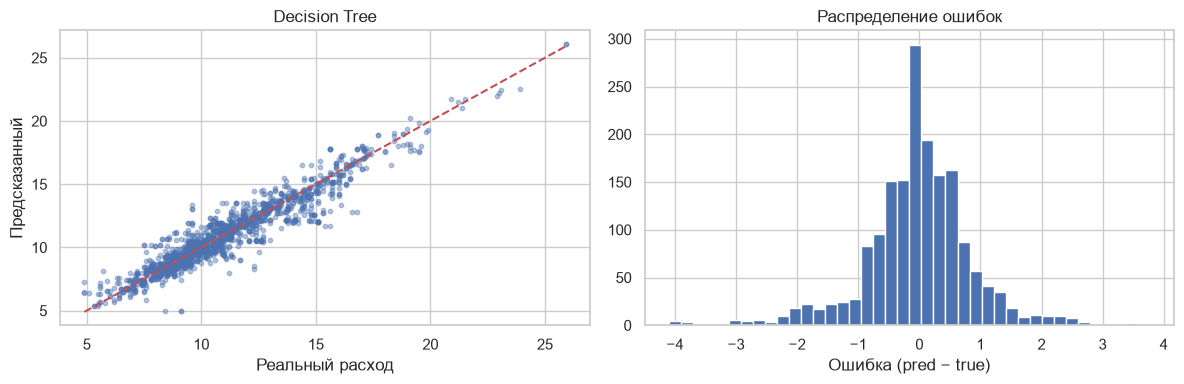


=== MAE по: Vehicle class


,n,MAE,bias
Vehicle class,,,
Pickup truck: Small,84,0.98,0.47
Subcompact,123,0.90,-0.59
Pickup truck: Standard,91,0.78,0.14
Sport utility vehicle: Standard,233,0.73,0.19
Station wagon: Mid-size,13,0.66,-0.14
Van: Passenger,10,0.63,-0.49
Special purpose vehicle,14,0.60,-0.06
Sport utility vehicle: Small,334,0.58,-0.00
Mid-size,226,0.57,0.02



=== MAE по: Fuel type


,n,MAE,bias
Fuel type,,,
E,69,0.90,-0.00
Z,832,0.65,-0.12
X,793,0.56,0.09
D,57,0.51,-0.00



=== MAE по: Cylinders


,n,MAE,bias
Cylinders,,,
16,1,0.80,-0.80
8,320,0.71,-0.27
6,528,0.65,0.08
4,812,0.58,0.03
10,18,0.46,-0.20
3,16,0.43,0.10
12,55,0.40,-0.15
5,1,0.20,-0.20



=== MAE по: is_hybrid


,n,MAE,bias
is_hybrid,,,
True,45,1.03,0.96
False,1706,0.60,-0.04


,Make,Model,Vehicle class,Fuel type,Engine size (L),y_true,y_pred,abs_error
7903,Honda,accord sport/touring,Full-size,X,2.0,9.1,5.00,4.10
8878,Honda,accord sport/touring,Full-size,X,2.0,9.1,5.00,4.10
1926,Mitsubishi,lancer evolution,Compact,Z,2.0,12.3,8.30,4.00
1292,Chevrolet,camaro zl1,Compact,Z,6.2,16.8,12.80,4.00
3480,Chevrolet,camaro zl1,Subcompact,Z,6.2,15.6,11.70,3.90
823,Mitsubishi,lancer evolution,Compact,Z,2.0,12.3,8.50,3.80
193,Chevrolet,camaro zl1,Compact,Z,6.2,16.6,12.80,3.80
8755,Ford,explorer hybrid awd,Sport utility vehicle: Standard,X,3.3,9.6,13.38,3.78
4540,Chevrolet,camaro zl1,Subcompact,Z,6.2,15.4,11.70,3.70
7774,Ford,explorer hybrid awd,Sport utility vehicle: Standard,X,3.3,9.6,13.07,3.47


In [40]:
y_pred = test_preds[best_name]
err = X_test.copy()
err["y_true"] = y_test.values
err["y_pred"] = y_pred
err["error"] = err["y_pred"] - err["y_true"]       # >0: модель завышает расход
err["abs_error"] = err["error"].abs()
err[["Make", "Model"]] = df.loc[X_test.index, ["Make", "Model"]]
err["is_hybrid"] = err["Model"].str.contains("hybrid", case=False)

# 1. Общая картина
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(err["y_true"], err["y_pred"], s=10, alpha=0.4)
lims = [err["y_true"].min(), err["y_true"].max()]
ax[0].plot(lims, lims, "r--")
ax[0].set_xlabel("Реальный расход"); ax[0].set_ylabel("Предсказанный"); ax[0].set_title(best_name)
ax[1].hist(err["error"], bins=40)
ax[1].set_xlabel("Ошибка (pred − true)"); ax[1].set_title("Распределение ошибок")
plt.tight_layout(); plt.show()

# 2. Срезы
def by(col):
    return (err.groupby(col)
            .agg(n=("abs_error", "size"), MAE=("abs_error", "mean"), bias=("error", "mean"))
            .round(2).sort_values("MAE", ascending=False))

for col in ["Vehicle class", "Fuel type", "Cylinders", "is_hybrid"]:
    print(f"\n=== MAE по: {col}")
    display(by(col))

# 3. Топ-10 худших ошибок
cols = ["Make", "Model", "Vehicle class", "Fuel type", "Engine size (L)", "y_true", "y_pred", "abs_error"]
err.sort_values("abs_error", ascending=False)[cols].head(10).round(2)

## 7.9 Итоги этапа 7

**Сравнение моделей (test):** см. таблицу в 7.7.

- Лучшая модель: **Decision Tree** (MAE = 0.615, R² = 0.901), что в
  **3,6 раза** лучше baseline (MAE 2.211).
- Критерий успеха: **выполнен** (MAE минимум вдвое ниже baseline,
  R² ≥ 0,8).
- Cross-validation: MAE = 0.703 ± 0.026, результат **стабилен**.
  Порядок моделей (Decision Tree, KNN, Linear Regression) совпадает с
  validation и test.
- Масштабирование не использовалось (требование проекта). Для Linear
  Regression и Decision Tree это не влияет на результат, а KNN от
  этого проиграл (MAE 0.715 на test, 0.746 на validation).

**Ограничения:**

- В данных нет веса и мощности автомобиля, вместо них используем
  объём двигателя, цилиндры и класс. Поэтому «заряженные» версии
  (Camaro ZL1, Lancer Evolution) модель занижает на 3.7-4.0 л/100 км.
- Признака «гибрид» нет, и гибридам расход завышается в среднем на
  0.96 л/100 км (45 машин в test).
- Редкие группы (5 и 16 цилиндров, Van: Cargo, E85) оцениваются по
  малому числу примеров, надёжных выводов по ним нет.
- Decision Tree с `max_depth=None` переобучен (MAE train 0.314 против
  0.662 на validation), хотя и лучший из трёх.
- Split случайный по группам, поэтому состав test зависит от
  `RANDOM_STATE`. MAE на test (0.615) ниже CV (0.703), и это нужно
  учитывать при оценке.

**Открытые проблемы и план на final:**

- Подбор гиперпараметров дерева через GridSearchCV с GroupKFold
  (`max_depth`, `min_samples_leaf`).
- Признак `is_hybrid` по названию модели и повторная оценка гибридов.
- Проверка по времени: обучение на 2014-2023, тест на 2024-2025.
- Отдельное обсуждение E85 и «заряженных» версий; KNN без
  `Model year` (0.715 вместо 0.746 на validation).